# Chapter 49 — Calibration and Traceability
**Modern Strain Gage Technology — Companion Notebook**

*Without calibration a measurement is only an opinion; with calibration — and an unbroken chain of comparisons back to the SI — it becomes a claim that can be defended.*

Companion notebook to Chapter 49 — Calibration and Traceability.

Calibration establishes a quantitative relationship between an instrument's output and the true value of the measurand. That relationship — the calibration curve — is not just a number; it is evidence. It says: when this instrument reads X, the true value is Y, and the difference Y − X is bounded by an uncertainty that has been rigorously evaluated. Without calibration, a measurement is an opinion. With calibration, it is a claim that can be checked.

*Traceability* means the calibration curve is connected, through an unbroken chain of comparisons with stated uncertainties, to a national or international measurement standard — in practice, to the SI unit system as realized by a national metrology institute such as NIST, PTB, or NPL. Every link in the chain introduces additional uncertainty; the final expanded uncertainty U on a calibration certificate reflects the accumulation of all those links. A high-precision force calibration laboratory maintains its own reference standard calibrated against a national standard, which it then uses to calibrate working standards used on the shop floor.

The calibration curve is characterized by fitting the input-output data to a model (usually linear), computing the residuals, and quantifying the deviation from the model as a component of the measurement uncertainty. A residual plot is the most sensitive diagnostic for non-linearity, systematic bias, and outliers — all of which would corrupt the calibration if left undetected.

**This notebook demonstrates:**
1. Multi-point calibration-curve fitting in strain units — sensitivity (slope) and offset (intercept) derivation, a 95% confidence band, and residual analysis, with a note on what R² does and does not show.

In [1]:
# Colab setup: install third-party dependencies (harmless no-op if already present).
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All generated figures are written here; the book includes this exact path.
OUT_DIR = Path("../src/media/ch49")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Calibration Curve, Best-Fit Sensitivity, and Residuals

The data below is a synthetic multi-point calibration in **strain units**: eleven applied reference strain levels from 0 to 2000 $\mu\varepsilon$, each paired with the system's *indicated* strain. The indicated values carry a deliberate 1.0% span (gain) error, a small 4 $\mu\varepsilon$ zero offset, and realistic per-reading noise, so the exercise mirrors what a real calibration against a reference standard reveals. The best-fit line through these eleven points establishes the system **sensitivity** — the slope, in indicated $\mu\varepsilon$ per applied $\mu\varepsilon$ — while the intercept captures the zero offset that must be subtracted from every subsequent reading. This is the calibration curve the chapter plots as Figure 49.1.

The gap between the fitted line and the ideal 1:1 line is the *systematic error* the calibration exists to expose: correct for it and the measurement improves; ignore it and the bias rides silently into every result. The 95% confidence band around the fit — computed from the residual standard deviation and Student's *t* for the nine degrees of freedom — bounds how well the slope and intercept are known from these eleven points.

The residual plot (right panel) is the key diagnostic. Residuals should be small, random, and centered on zero with no systematic trend. A systematic S-curve would signal nonlinearity the straight-line model misses; a fan-shaped spread that grows with load would signal heteroscedasticity (noise proportional to signal). Here the residuals are random and bounded within a narrow band, confirming that the linear model is adequate across the range.

The $R^2$ statistic sits just below unity, and it is *not* the evidence for linearity. Over a wide calibration range almost any monotonic response, curved or straight, gives an $R^2$ within a hair of 1. The code prints $(1 - R^2)\times 10^6$ alongside the raw value, but that number is the fraction of variance the line leaves unexplained, and here it is set almost entirely by the random noise, not by any curvature. The residual plot is where linearity is judged: residuals that scatter randomly about zero, with no S-shape or trend across the range, show that a straight line describes the system.

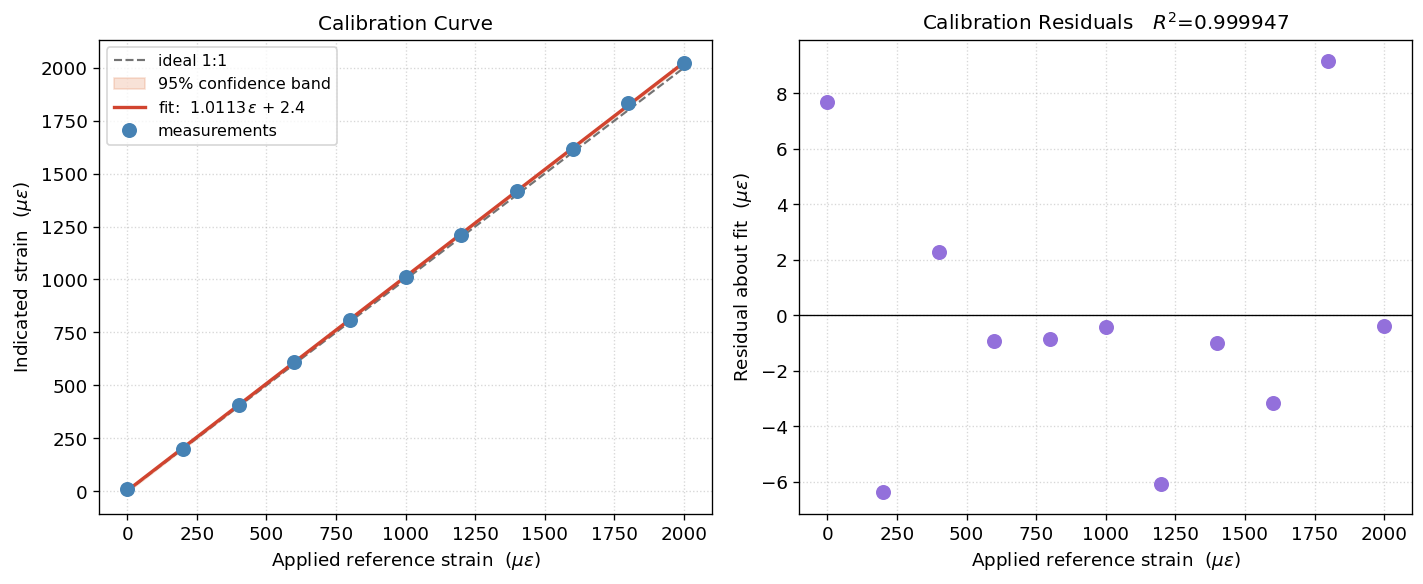

best-fit gain (sensitivity) = 1.0113 ue/ue
best-fit offset             = 2.43 ue
R^2                         = 0.999947  (53.0 ppm from unity)


In [2]:
# Calibration curve in strain units: applied reference strain vs. the system's
# indicated strain, with the ideal 1:1 line, a least-squares fit, its 95%
# confidence band, and the residuals about the fit.

# --- Reproducible synthetic calibration data --------------------------------
SEED = 3
N_POINTS = 11              # number of calibration levels
STRAIN_MAX = 2000.0        # full-scale applied strain (microstrain)
GAIN_TRUE = 1.010          # built-in 1.0% span (gain) error
OFFSET_TRUE = 4.0          # built-in zero offset (microstrain)
NOISE_STD = 3.0            # per-reading noise, 1 sigma (microstrain)
T_CRIT_95 = 2.262          # Student t, 0.975 quantile, dof = N_POINTS - 2 = 9

rng = np.random.default_rng(SEED)
eps_ref = np.linspace(0, STRAIN_MAX, N_POINTS)                                  # applied reference strain (ue)
eps_ind = GAIN_TRUE * eps_ref + OFFSET_TRUE + rng.normal(0, NOISE_STD, eps_ref.size)  # indicated strain (ue)


def fit_least_squares(x, y):
    """Ordinary least-squares straight-line fit y = slope * x + intercept.

    Returns the slope, intercept, per-point residuals, the residual standard
    deviation s (with n - 2 degrees of freedom), the mean of x, and
    Sxx = sum((x - xbar)**2). The last two feed the confidence-band formula.
    """
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.sum((x - xbar) ** 2)
    slope = np.sum((x - xbar) * (y - ybar)) / Sxx
    intercept = ybar - slope * xbar
    residuals = y - (slope * x + intercept)
    dof = x.size - 2
    s = np.sqrt(np.sum(residuals ** 2) / dof)
    return slope, intercept, residuals, s, xbar, Sxx


slope, intercept, resid, s, xbar, Sxx = fit_least_squares(eps_ref, eps_ind)
ybar = eps_ind.mean()
R2 = 1 - np.sum(resid ** 2) / np.sum((eps_ind - ybar) ** 2)
nonlinearity_ppm = (1 - R2) * 1e6           # deviation from a perfect line (parts per million)

# Smooth grid for the fit line and its 95% confidence band.
xg = np.linspace(0, STRAIN_MAX, 200)
yg = slope * xg + intercept
ci = T_CRIT_95 * s * np.sqrt(1.0 / eps_ref.size + (xg - xbar) ** 2 / Sxx)

# --- Plot -------------------------------------------------------------------
BLUE, RED, BAND, PURPLE = 'steelblue', '#d1442f', '#e0703a', 'mediumpurple'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot([0, STRAIN_MAX], [0, STRAIN_MAX], '--', color='0.45', lw=1.3, label='ideal 1:1', zorder=2)
ax.fill_between(xg, yg - ci, yg + ci, color=BAND, alpha=0.20, label='95% confidence band', zorder=1)
ax.plot(xg, yg, color=RED, lw=2.0, label=rf'fit:  {slope:.4f}$\,\varepsilon$ + {intercept:.1f}', zorder=3)
ax.plot(eps_ref, eps_ind, 'o', color=BLUE, ms=8, zorder=4, label='measurements')
ax.set_xlabel(r'Applied reference strain  ($\mu\varepsilon$)')
ax.set_ylabel(r'Indicated strain  ($\mu\varepsilon$)')
ax.set_title('Calibration Curve')
ax.legend(fontsize=9.5, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[1]
ax.axhline(0, color='black', lw=0.8)
ax.plot(eps_ref, resid, 'o', color=PURPLE, ms=8)
ax.set_xlabel(r'Applied reference strain  ($\mu\varepsilon$)')
ax.set_ylabel(r'Residual about fit  ($\mu\varepsilon$)')
ax.set_title(rf'Calibration Residuals   $R^2$={R2:.6f}')
ax.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig49_nb1_calibration_curve.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

print(f'best-fit gain (sensitivity) = {slope:.4f} ue/ue')
print(f'best-fit offset             = {intercept:.2f} ue')
print(f'R^2                         = {R2:.6f}  ({nonlinearity_ppm:.1f} ppm from unity)')

---
## Where to take this next

- **Add shunt calibration.** Implement Eqs. 49.1–49.2 from the chapter: for a 120 Ω, GF = 2.00 gage, compute the shunt resistor that produces exactly 1000 $\mu\varepsilon$ of apparent strain (you should recover 59,880 Ω), then run that known stimulus through this same fitting machinery to gain-check the electronic portion of the chain.
- **Propagate the certificate uncertainty.** Give the reference strain its own expanded uncertainty (say ±0.05% at *k* = 2) and combine it with the fit's confidence band into a single uncertainty on every corrected reading — the direct bridge back to the uncertainty budget of the preceding chapter.
- **Apply and verify the correction.** Invert the fitted line to correct a fresh batch of indicated readings, then confirm the corrected values scatter about the ideal 1:1 line with only the residual (post-correction) uncertainty left — the "use the certificate, don't just file it" argument the chapter closes on.